# CNN+Transformer Robustness Test

Error 혼입 비율(0, 20, 40, 60, 80%)에 따라
- Single model inference
- Soft voting inference (MC Dropout)
의 Test Accuracy 변화를 비교합니다.

In [6]:
import os
import pickle
import math
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from scipy.signal import resample_poly, find_peaks, butter, filtfilt
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda:0


In [7]:
# Config
DATASET_PATH = '/home/binghin2/Myproject/Dataset/WESAD'
TEST_USERS = ['S15', 'S16', 'S17']
TARGET_LABELS = {1: 0, 2: 1, 3: 2}
DOWNSAMPLE_RATE = 4
WINDOW_SIZE_SEC = 60
TEST_STRIDE_SEC = 60
LABEL_PURITY_THRESHOLD = 0.8
N_FEATURES = 10
BATCH_SIZE = 64
CLASS_NAMES = ['Baseline', 'Stress', 'Amusement']

# Trained checkpoint path (원하면 다른 체크포인트로 교체)
MODEL_PATH = '/home/binghin2/Myproject/Research/WESAD_classification/Training/CNN_TF/Save_model/CT_0313_focal_model.pt'

# Robustness experiment settings
ERROR_RATES = [0.0, 0.2, 0.4, 0.6, 0.8]
NOISE_STD = 2.0      # 강한 오염
N_VOTES = 10         # soft voting 횟수


def _to_2d_column(signal):
    signal = np.asarray(signal)
    if signal.ndim == 1:
        return signal.reshape(-1, 1)
    return signal


def _resample_signal(signal, orig_rate, target_rate):
    signal_2d = _to_2d_column(signal)
    if orig_rate == target_rate:
        return signal_2d
    return resample_poly(signal_2d, up=target_rate, down=orig_rate, axis=0)


def decompose_eda_scl_scr(eda, fs=4, cutoff_hz=0.05, order=2):
    eda_flat = np.asarray(eda).reshape(-1).astype(float)
    nyq = 0.5 * fs
    normalized_cutoff = cutoff_hz / nyq
    b, a = butter(order, normalized_cutoff, btype='low')

    if len(eda_flat) <= (max(len(a), len(b)) * 3):
        scl = np.copy(eda_flat)
    else:
        scl = filtfilt(b, a, eda_flat)

    scr = eda_flat - scl
    return scl.reshape(-1, 1), scr.reshape(-1, 1)


def extract_bvp_features(bvp, orig_rate=64, target_rate=4):
    bvp_flat = np.asarray(bvp).flatten()

    min_distance = int(orig_rate * 0.3)
    peaks, _ = find_peaks(bvp_flat, distance=min_distance)

    times_orig = np.arange(len(bvp_flat)) / float(orig_rate)
    target_len = int(np.ceil(len(bvp_flat) * target_rate / float(orig_rate)))
    times_target = np.arange(target_len) / float(target_rate)

    if len(peaks) > 1:
        peak_times = times_orig[peaks]
        ibi = np.diff(peak_times)
        hr = 60.0 / np.clip(ibi, 1e-6, None)
        peak_times = peak_times[1:]

        hr_continuous = np.interp(times_target, peak_times, hr)
        ibi_continuous = np.interp(times_target, peak_times, ibi)

        ibi_series = pd.Series(ibi_continuous)
        hrv_continuous = (
            ibi_series
            .rolling(window=target_rate * 10, min_periods=1)
            .std()
            .fillna(0.0)
            .values
        )
    else:
        hr_continuous = np.zeros(target_len)
        ibi_continuous = np.zeros(target_len)
        hrv_continuous = np.zeros(target_len)

    return np.concatenate([
        hr_continuous.reshape(-1, 1),
        ibi_continuous.reshape(-1, 1),
        hrv_continuous.reshape(-1, 1)
    ], axis=1)


def load_and_preprocess_data(subject_path):
    with open(subject_path, 'rb') as f:
        data = pickle.load(f, encoding='latin1')

    wrist_data = data['signal']['wrist']
    acc = wrist_data['ACC']
    bvp = wrist_data['BVP']
    eda = wrist_data['EDA']
    temp = wrist_data['TEMP']
    labels = data['label']

    bvp_features = extract_bvp_features(bvp, orig_rate=64, target_rate=DOWNSAMPLE_RATE)
    scl_eda, scr_eda = decompose_eda_scl_scr(eda, fs=4, cutoff_hz=0.05, order=2)

    acc_down = _resample_signal(acc, orig_rate=32, target_rate=DOWNSAMPLE_RATE)
    bvp_down = _resample_signal(bvp, orig_rate=64, target_rate=DOWNSAMPLE_RATE)
    scl_down = _resample_signal(scl_eda, orig_rate=4, target_rate=DOWNSAMPLE_RATE)
    scr_down = _resample_signal(scr_eda, orig_rate=4, target_rate=DOWNSAMPLE_RATE)
    temp_down = _resample_signal(temp, orig_rate=4, target_rate=DOWNSAMPLE_RATE)

    label_timestamps = np.arange(len(labels)) / 700.0
    data_timestamps = np.arange(len(acc_down)) / float(DOWNSAMPLE_RATE)
    idx = np.searchsorted(label_timestamps, data_timestamps, side='left')
    idx = np.clip(idx, 0, len(labels) - 1)
    labels_down = labels[idx].astype(int)

    min_len = min(
        len(acc_down), len(bvp_down), len(scl_down), len(scr_down),
        len(temp_down), len(bvp_features), len(labels_down)
    )

    features = np.concatenate([
        acc_down[:min_len],
        bvp_down[:min_len],
        scl_down[:min_len],
        scr_down[:min_len],
        temp_down[:min_len],
        bvp_features[:min_len]
    ], axis=1)

    features_scaled = (features - features.mean(axis=0)) / (features.std(axis=0) + 1e-8)
    return features_scaled, labels_down[:min_len]


def create_windows(features, labels, stride_sec):
    window_samples = WINDOW_SIZE_SEC * DOWNSAMPLE_RATE
    stride_samples = max(1, int(stride_sec * DOWNSAMPLE_RATE))

    X, y = [], []
    i = 0
    max_start = len(features) - window_samples

    while i <= max_start:
        window_features = features[i : i + window_samples]
        window_labels = labels[i : i + window_samples].astype(int)

        counts = np.bincount(window_labels)
        if counts.size == 0:
            i += stride_samples
            continue

        dominant = int(counts.argmax())
        purity = counts[dominant] / float(window_samples)

        if dominant in TARGET_LABELS and purity >= LABEL_PURITY_THRESHOLD:
            X.append(window_features)
            y.append(TARGET_LABELS[dominant])

        i += stride_samples

    return np.array(X), np.array(y)


def build_test_set():
    test_X, test_y = [], []
    for user in TEST_USERS:
        subject_path = os.path.join(DATASET_PATH, user, f'{user}.pkl')
        if os.path.exists(subject_path):
            print(f'Processing TEST user: {user}...')
            features, labels = load_and_preprocess_data(subject_path)
            X_user, y_user = create_windows(features, labels, stride_sec=TEST_STRIDE_SEC)
            if X_user.size > 0:
                test_X.append(X_user)
                test_y.append(y_user)

    if len(test_X) == 0:
        raise ValueError('No test data found. Check TEST_USERS or DATASET_PATH.')

    X_test = np.concatenate(test_X, axis=0)
    y_test = np.concatenate(test_y, axis=0)
    return X_test, y_test


X_test, y_test = build_test_set()
print(f'\nTest set shape: {X_test.shape}')
print(f'Test label distribution: {np.bincount(y_test)}')

Processing TEST user: S15...
Processing TEST user: S16...
Processing TEST user: S17...

Test set shape: (108, 240, 10)
Test label distribution: [57 33 18]


In [8]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]


class CNNTransformerModel(nn.Module):
    def __init__(
        self, input_dim, cnn_out_channels, cnn_kernel_size, cnn_pool_size,
        d_model, nhead, dim_feedforward, nlayers, output_dim, dropout=0.5
    ):
        super().__init__()
        self.conv1 = nn.Conv1d(input_dim, cnn_out_channels, kernel_size=cnn_kernel_size, padding=1)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool1d(cnn_pool_size)

        self.conv2 = nn.Conv1d(cnn_out_channels, cnn_out_channels, kernel_size=cnn_kernel_size, padding=1)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool1d(cnn_pool_size)

        self.cnn_to_transformer = nn.Linear(cnn_out_channels, d_model)
        self.pos_encoder = PositionalEncoding(d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=nlayers)
        self.fc = nn.Linear(d_model, output_dim)

    def forward(self, x):
        x = x.transpose(1, 2)
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = x.transpose(1, 2)
        x = self.cnn_to_transformer(x)
        x = self.pos_encoder(x)
        x = self.transformer_encoder(x)
        x = x[:, -1, :]
        x = self.fc(x)
        return x


def load_model_from_checkpoint(model_path):
    checkpoint = torch.load(model_path, map_location=device)
    model = CNNTransformerModel(
        input_dim=checkpoint['n_features'],
        cnn_out_channels=checkpoint['cnn_out_channels'],
        cnn_kernel_size=checkpoint['cnn_kernel_size'],
        cnn_pool_size=checkpoint['cnn_pool_size'],
        d_model=checkpoint['d_model'],
        nhead=checkpoint['nhead'],
        dim_feedforward=checkpoint['dim_feedforward'],
        nlayers=checkpoint['nlayers'],
        output_dim=checkpoint['output_dim'],
        dropout=0.5,
    )
    model.load_state_dict(checkpoint['model_state_dict'])
    model.to(device)
    return model


model = load_model_from_checkpoint(MODEL_PATH)
print(f'Model loaded from: {MODEL_PATH}')

Model loaded from: /home/binghin2/Myproject/Research/WESAD_classification/Training/CNN_TF/Save_model/CT_0313_focal_model.pt


/tmp/ipykernel_31950/3483386531.py:59: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path, map_location=device)


In [9]:
class NumpyDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def inject_gaussian_error_batch(x, error_rate=0.0, noise_std=2.0):
    # x: (batch, seq_len, n_features)
    if error_rate <= 0.0:
        return x

    x_noisy = x.clone()
    bsz = x_noisy.size(0)
    num_corrupt = int(round(bsz * error_rate))
    if num_corrupt == 0:
        return x_noisy

    idx = torch.randperm(bsz, device=x_noisy.device)[:num_corrupt]
    noise = torch.randn_like(x_noisy[idx]) * noise_std
    x_noisy[idx] = x_noisy[idx] + noise
    return x_noisy


def enable_dropout_modules(model):
    # eval 상태에서도 dropout 모듈만 train으로 전환 (MC Dropout)
    for m in model.modules():
        if isinstance(m, nn.Dropout):
            m.train()


@torch.no_grad()
def evaluate_single_model(model, data_loader, error_rate, noise_std):
    model.eval()
    correct = 0
    total = 0
    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)
        x = inject_gaussian_error_batch(x, error_rate=error_rate, noise_std=noise_std)
        logits = model(x)
        pred = torch.argmax(logits, dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)
    return (100.0 * correct / total) if total > 0 else 0.0


@torch.no_grad()
def evaluate_soft_voting_mc_dropout(model, data_loader, error_rate, noise_std, n_votes=10):
    model.eval()
    enable_dropout_modules(model)

    correct = 0
    total = 0
    for x, y in data_loader:
        x = x.to(device)
        y = y.to(device)
        x = inject_gaussian_error_batch(x, error_rate=error_rate, noise_std=noise_std)

        probs_sum = None
        for _ in range(n_votes):
            logits = model(x)
            probs = torch.softmax(logits, dim=1)
            probs_sum = probs if probs_sum is None else (probs_sum + probs)

        probs_avg = probs_sum / float(n_votes)
        pred = torch.argmax(probs_avg, dim=1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return (100.0 * correct / total) if total > 0 else 0.0


def evaluate_robustness(model, X_test, y_test, error_rates, noise_std, batch_size=64, n_votes=10):
    loader = DataLoader(NumpyDataset(X_test, y_test), batch_size=batch_size, shuffle=False)
    rows = []

    for er in error_rates:
        acc_single = evaluate_single_model(model, loader, error_rate=er, noise_std=noise_std)
        acc_soft = evaluate_soft_voting_mc_dropout(
            model, loader, error_rate=er, noise_std=noise_std, n_votes=n_votes
        )
        rows.append({
            'error_rate': er,
            'error_rate_percent': er * 100.0,
            'single_acc': acc_single,
            'soft_voting_acc': acc_soft,
        })
        print(f'Error {er*100:>4.0f}% | Single: {acc_single:6.2f}% | SoftVoting(MC): {acc_soft:6.2f}%')

    return pd.DataFrame(rows)

Error    0% | Single:  76.85% | SoftVoting(MC):  76.85%
Error   20% | Single:  74.07% | SoftVoting(MC):  74.07%
Error   40% | Single:  76.85% | SoftVoting(MC):  74.07%
Error   60% | Single:  71.30% | SoftVoting(MC):  77.78%
Error   80% | Single:  71.30% | SoftVoting(MC):  72.22%

Robustness results


,error_rate,error_rate_percent,single_acc,soft_voting_acc
0,0.0,0.0,76.851852,76.851852
1,0.2,20.0,74.074074,74.074074
2,0.4,40.0,76.851852,74.074074
3,0.6,60.0,71.296296,77.777778
4,0.8,80.0,71.296296,72.222222


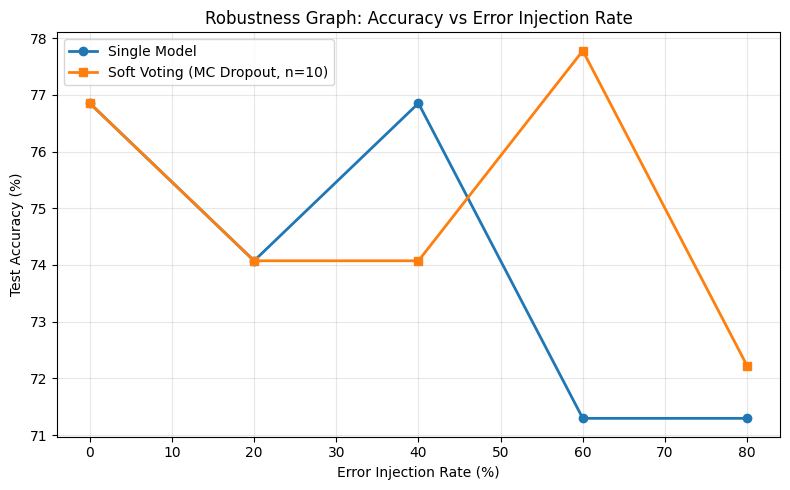

In [16]:
results_df = evaluate_robustness(
    model=model,
    X_test=X_test,
    y_test=y_test,
    error_rates=ERROR_RATES,
    noise_std=NOISE_STD,
    batch_size=BATCH_SIZE,
    n_votes=N_VOTES,
 )

print('\nRobustness results')
display(results_df)

plt.figure(figsize=(8, 5))
plt.plot(results_df['error_rate_percent'], results_df['single_acc'], marker='o', linewidth=2, label='Single Model')
plt.plot(results_df['error_rate_percent'], results_df['soft_voting_acc'], marker='s', linewidth=2, label=f'Soft Voting (MC Dropout, n={N_VOTES})')
plt.xlabel('Error Injection Rate (%)')
plt.ylabel('Test Accuracy (%)')
plt.title('Robustness Graph: Accuracy vs Error Injection Rate')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

100-run robustness summary (mean ± std)


,error_rate,error_rate_percent,single_mean,single_std,soft_mean,soft_std
0,0.0,0.0,76.851852,1.428245e-14,76.851852,1.428245e-14
1,0.2,20.0,75.870370,2.008093e+00,75.101852,1.933726e+00
2,0.4,40.0,74.009259,2.905038e+00,73.824074,2.747544e+00
3,0.6,60.0,72.574074,2.953889e+00,72.537037,3.058856e+00
4,0.8,80.0,71.175926,2.443239e+00,71.185185,2.829607e+00


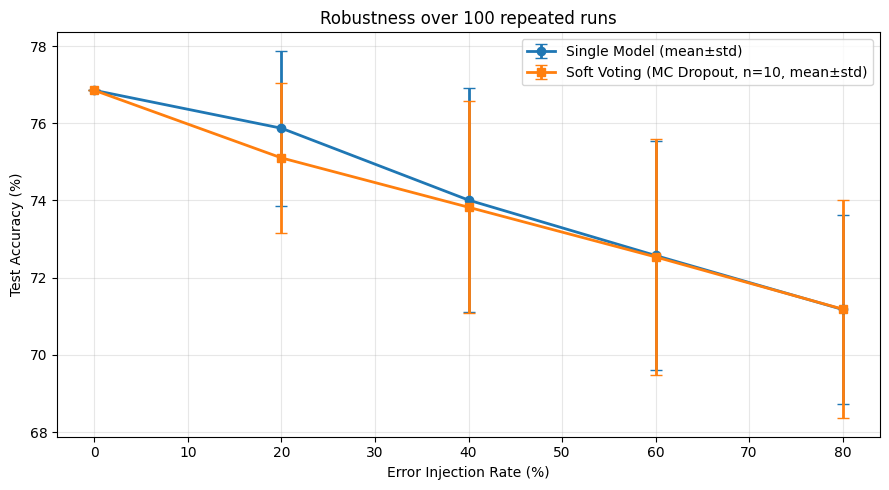

In [17]:
# 100회 반복 Robustness 실험 (평균 ± 표준편차)
N_REPEATS = 100

loader = DataLoader(NumpyDataset(X_test, y_test), batch_size=BATCH_SIZE, shuffle=False)

single_runs = {er: [] for er in ERROR_RATES}
soft_runs = {er: [] for er in ERROR_RATES}

for rep in range(N_REPEATS):
    for er in ERROR_RATES:
        acc_single = evaluate_single_model(model, loader, error_rate=er, noise_std=NOISE_STD)
        acc_soft = evaluate_soft_voting_mc_dropout(
            model, loader, error_rate=er, noise_std=NOISE_STD, n_votes=N_VOTES
        )
        single_runs[er].append(acc_single)
        soft_runs[er].append(acc_soft)

summary_rows = []
for er in ERROR_RATES:
    s_arr = np.array(single_runs[er], dtype=float)
    v_arr = np.array(soft_runs[er], dtype=float)
    summary_rows.append({
        "error_rate": er,
        "error_rate_percent": er * 100.0,
        "single_mean": s_arr.mean(),
        "single_std": s_arr.std(ddof=1),
        "soft_mean": v_arr.mean(),
        "soft_std": v_arr.std(ddof=1),
    })

robustness_100_df = pd.DataFrame(summary_rows)
print("100-run robustness summary (mean ± std)")
display(robustness_100_df)

x = robustness_100_df["error_rate_percent"].values
s_mean = robustness_100_df["single_mean"].values
s_std = robustness_100_df["single_std"].values
v_mean = robustness_100_df["soft_mean"].values
v_std = robustness_100_df["soft_std"].values

plt.figure(figsize=(9, 5))
plt.errorbar(x, s_mean, yerr=s_std, marker='o', capsize=4, linewidth=2, label='Single Model (mean±std)')
plt.errorbar(x, v_mean, yerr=v_std, marker='s', capsize=4, linewidth=2, label=f'Soft Voting (MC Dropout, n={N_VOTES}, mean±std)')
plt.xlabel('Error Injection Rate (%)')
plt.ylabel('Test Accuracy (%)')
plt.title(f'Robustness over {N_REPEATS} repeated runs')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()